In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# Load dataset
df = pd.read_csv("Social_Network_Ads.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)

Shape: (400, 5)

Columns:
 Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='str')

Data Types:
 User ID            int64
Gender               str
Age                int64
EstimatedSalary    int64
Purchased          int64
dtype: object


In [ ]:
numeric_cols = ["Age", "EstimatedSalary"]

for col in numeric_cols:
    df.loc[df.sample(frac=0.05, random_state=42).index, col] = np.nan

print("\nMissing Values After Injection:\n", df.isnull().sum())


Missing Values After Injection:
 User ID             0
Gender              0
Age                20
EstimatedSalary    20
Purchased           0
dtype: int64


In [3]:
print("\nStatistical Summary:\n", df.describe())


Statistical Summary:
             User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  380.000000       380.000000  400.000000
mean   1.569154e+07   37.565789     70126.315789    0.357500
std    7.165832e+04   10.445152     34412.979114    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   29.750000     43000.000000    0.000000
50%    1.569434e+07   37.000000     70000.000000    0.000000
75%    1.575036e+07   45.250000     88000.000000    1.000000
max    1.581524e+07   60.000000    150000.000000    1.000000


In [ ]:
print("\nGender Distribution:\n", df["Gender"].value_counts())
print("\nTarget Distribution:\n", df["Purchased"].value_counts())


Gender Distribution:
 Gender
Female    204
Male      196
Name: count, dtype: int64

Target Distribution:
 Purchased
0    257
1    143
Name: count, dtype: int64


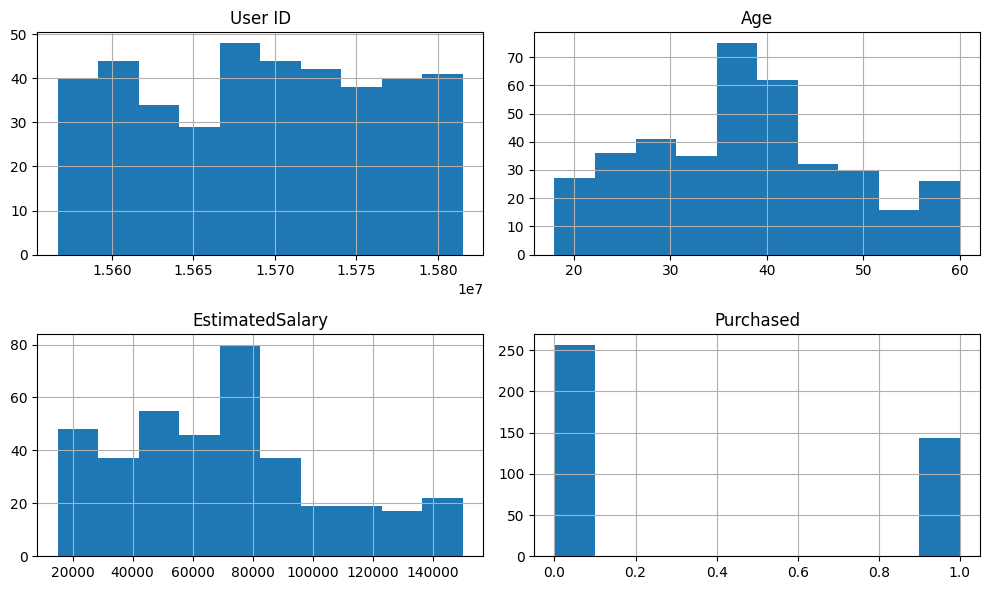

In [5]:
df.hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

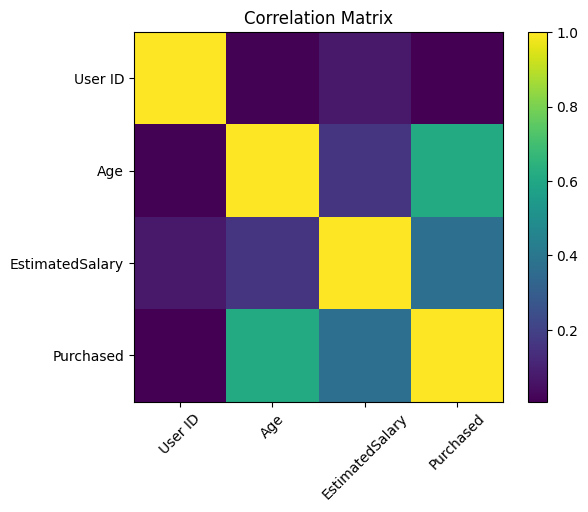

In [6]:
corr = df.corr(numeric_only=True)

plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

In [ ]:
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

In [ ]:
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [10]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return outliers

outlier_indices = set()

for col in ['Age', 'EstimatedSalary']:
    outliers = detect_outliers_iqr(df, col)
    outlier_indices.update(outliers.index)

print("Number of outliers detected:", len(outlier_indices))

Number of outliers detected: 0


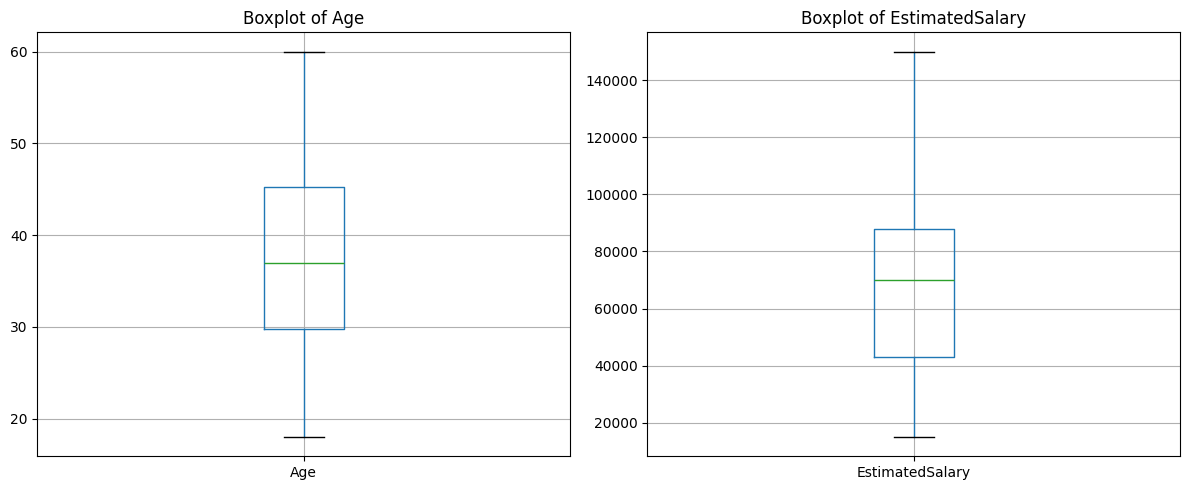

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(column='Age', ax=axes[0])
axes[0].set_title('Boxplot of Age')

df.boxplot(column='EstimatedSalary', ax=axes[1])
axes[1].set_title('Boxplot of EstimatedSalary')

plt.tight_layout()
plt.show()

In [ ]:
df_clean = df.drop(outlier_indices)

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

Original dataset shape: (400, 5)
Cleaned dataset shape: (400, 5)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nPreprocessing Completed Successfully!")


Preprocessing Completed Successfully!


In [14]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

TN, FP, FN, TP = cm.ravel()

print("\nTP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)


Confusion Matrix:
 [[65  3]
 [11 21]]

TP: 21
TN: 65
FP: 3
FN: 11


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
error_rate = 1 - accuracy

print("\nAccuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)


Accuracy: 0.86
Error Rate: 0.14
Precision: 0.875
Recall: 0.65625
